# Spotify Trend Analyzer — Exploratory Data Analysis

**Goal:** Combine artist popularity data with song-level audio features and chart performance, then explore relationships that inform three research questions:

1. **Brand vs. Signal** — Does artist popularity moderate the link between spectral brightness and chart rank?
2. **Longevity Paradox** — How does collaboration count × harmonic stability predict chart decay?
3. **Popularity Premium** — How much of a song's streams are unexplained by audio features alone (brand power)?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120

songs = pd.read_csv("processed_chart_tracks_audio_features.csv")
artists = pd.read_csv("raw_artist_popularity_scores.csv")

print(f"Songs  : {songs.shape[0]:,} rows × {songs.shape[1]} cols")
print(f"Artists: {artists.shape[0]:,} rows × {artists.shape[1]} cols")

Songs  : 13,399 rows × 19 cols
Artists: 711 rows × 2 cols


## 1. Merging the Datasets & Adding Artist Features

**Strategy:** Songs can have multiple artists (e.g. `"Bad Bunny, JHAYCO"`).  
We split `artist_names`, look up each artist's popularity, then keep the **primary artist's popularity** (first listed) and the **max popularity** across all credited artists.  
We also derive:
- **`feature_count`** (number of artists on a track) — critical for Research Question 2.
- **`monthly_listeners`** scraped from [kworb.net](https://kworb.net/spotify/listeners.html) — critical for Research Question 1, which asks whether monthly listeners moderate the brightness–rank relationship.

In [2]:
pop_lookup = artists.set_index("artist_name")["popularity_score"].to_dict()

def parse_artists(raw):
    """Split the artist_names field and return a list of individual names."""
    if pd.isna(raw):
        return []
    return [a.strip() for a in str(raw).split(",")]

songs["artist_list"] = songs["artist_names"].apply(parse_artists)
songs["feature_count"] = songs["artist_list"].apply(len)

songs["primary_artist"] = songs["artist_list"].apply(lambda x: x[0] if x else None)
songs["primary_artist_popularity"] = songs["primary_artist"].map(pop_lookup)

songs["max_artist_popularity"] = songs["artist_list"].apply(
    lambda lst: max((pop_lookup.get(a, np.nan) for a in lst), default=np.nan)
)

matched = songs["primary_artist_popularity"].notna().sum()
total = len(songs)
print(f"Primary-artist popularity matched: {matched:,} / {total:,} ({matched/total:.1%})")
print(f"Feature count range: {songs['feature_count'].min()} – {songs['feature_count'].max()}")
songs.head(3)

Primary-artist popularity matched: 13,399 / 13,399 (100.0%)
Feature count range: 1 – 9


,rank,uri,artist_names,track_name,source,peak_rank,previous_rank,weeks_on_chart,streams,date,...,spectral_rolloff,mfcc_1,mfcc_2,chroma_mean,chroma_std,artist_list,feature_count,primary_artist,primary_artist_popularity,max_artist_popularity
0,1,spotify:track:4MzXwWMhyBbmu6hOcLVD49,"Bad Bunny, JHAYCO",DÁKITI,Rimas Entertainment LLC,1,1,10,31544941,2021-01-07,...,4562.384912,-184.321533,103.523415,0.353403,0.298455,"[Bad Bunny, JHAYCO]",2,Bad Bunny,100,100
1,2,spotify:track:3tjFYV6RSFtuktYl3ZtYcq,"24kGoldn, iann dior",Mood (feat. iann dior),Records/Columbia,1,2,22,23461354,2021-01-07,...,4641.426101,-69.552780,93.771202,0.336845,0.299802,"[24kGoldn, iann dior]",2,24kGoldn,68,68
2,3,spotify:track:0VjIjW4GlUZAMYd2vXMi3b,The Weeknd,Blinding Lights,Republic Records,1,5,58,22981042,2021-01-07,...,3815.926926,-81.836159,109.673134,0.465111,0.293015,[The Weeknd],1,The Weeknd,94,94


In [3]:
import requests
import lxml

def get_kworb_listeners():
    """Scrape the full monthly-listeners table from kworb.net into a dict {artist_lower: listeners}."""
    all_data = {}
    for i in range(1, 6):
        url = "https://kworb.net/spotify/listeners.html" if i == 1 else f"https://kworb.net/spotify/listeners{i}.html"
        try:
            tables = pd.read_html(url)
            tbl = tables[0][["Artist", "Listeners"]]
            tbl["Listeners"] = tbl["Listeners"].astype(str).str.replace(",", "").astype(int)
            for _, row in tbl.iterrows():
                all_data[row["Artist"].lower()] = row["Listeners"]
        except Exception:
            break
    return all_data

listeners_dict = get_kworb_listeners()
print(f"Scraped {len(listeners_dict):,} artists from kworb.net")

songs["monthly_listeners"] = songs["primary_artist"].apply(
    lambda x: listeners_dict.get(x.strip().lower(), np.nan) if pd.notna(x) else np.nan
)

matched_ml = songs["monthly_listeners"].notna().sum()
print(f"Monthly listeners matched: {matched_ml:,} / {len(songs):,} ({matched_ml/len(songs):.1%})")
print(f"Listener range: {songs['monthly_listeners'].min():,.0f} – {songs['monthly_listeners'].max():,.0f}")

Scraped 12,466 artists from kworb.net
Monthly listeners matched: 13,248 / 13,399 (98.9%)
Listener range: 1,225,120 – 135,026,913


## 2. Data Overview

In [4]:
songs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13399 entries, 0 to 13398
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   rank                       13399 non-null  int64  
 1   uri                        13399 non-null  object 
 2   artist_names               13399 non-null  object 
 3   track_name                 13399 non-null  object 
 4   source                     13399 non-null  object 
 5   peak_rank                  13399 non-null  int64  
 6   previous_rank              13399 non-null  int64  
 7   weeks_on_chart             13399 non-null  int64  
 8   streams                    13399 non-null  int64  
 9   date                       13399 non-null  object 
 10  tempo                      13399 non-null  float64
 11  energy                     13399 non-null  float64
 12  zero_crossing_rate         13399 non-null  float64
 13  spectral_centroid          13399 non-null  flo

In [5]:
songs.describe()

,rank,peak_rank,previous_rank,weeks_on_chart,streams,tempo,energy,zero_crossing_rate,spectral_centroid,spectral_rolloff,mfcc_1,mfcc_2,chroma_mean,chroma_std,feature_count,primary_artist_popularity,max_artist_popularity,monthly_listeners
count,13399.000000,13399.000000,13399.000000,13399.000000,1.339900e+04,13399.000000,13399.000000,13399.000000,13399.000000,13399.000000,13399.000000,13399.000000,13399.000000,13399.000000,13399.000000,13399.000000,13399.000000,1.324800e+04
mean,25.499142,12.283081,25.460631,28.357265,2.054406e+07,118.853649,0.200398,0.084332,2119.096498,4525.181216,-123.907314,97.861403,0.366980,0.304054,1.504739,83.753937,85.192253,5.059831e+07
std,14.431605,12.155758,21.133800,38.707473,9.951141e+06,26.888681,0.067886,0.024892,453.760322,1062.316780,59.215531,21.232266,0.060616,0.009663,0.892131,9.920063,9.681588,3.328962e+07
min,1.000000,1.000000,-1.000000,1.000000,8.986185e+06,57.421875,0.024096,0.021247,711.367186,1204.505217,-371.387909,35.673634,0.194463,0.228243,1.000000,15.000000,15.000000,1.225120e+06
25%,13.000000,3.000000,10.000000,6.000000,1.467199e+07,99.384014,0.151155,0.067823,1791.636124,3803.222836,-157.117340,83.195396,0.325696,0.297790,1.000000,78.000000,80.000000,2.387499e+07
50%,25.000000,8.000000,23.000000,15.000000,1.748471e+07,117.453835,0.208470,0.080870,2126.608102,4555.159956,-114.533440,97.153557,0.365006,0.304095,1.000000,86.000000,86.000000,4.602804e+07
75%,38.000000,18.000000,37.000000,33.000000,2.308419e+07,135.999178,0.248366,0.099413,2410.395945,5241.776637,-82.930771,111.530083,0.407349,0.310420,2.000000,90.000000,91.000000,7.262369e+07
max,50.000000,50.000000,200.000000,318.000000,1.288961e+08,258.398438,0.535717,0.189798,3700.933609,7617.824769,52.788639,176.892929,0.695488,0.346676,9.000000,100.000000,100.000000,1.350269e+08


In [6]:
missing = songs.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("=== Missing values ===")
print(missing.to_string())
hashable_cols = [c for c in songs.columns if c != "artist_list"]
print(f"\nDuplicate rows (excl. artist_list): {songs.duplicated(subset=hashable_cols).sum()}")
print(f"Unique tracks (by uri):   {songs['uri'].nunique()}")
print(f"Unique dates:             {songs['date'].nunique()}")
print(f"Date range:               {songs['date'].min()} → {songs['date'].max()}")

=== Missing values ===
monthly_listeners    151

Duplicate rows (excl. artist_list): 0
Unique tracks (by uri):   1580
Unique dates:             268
Date range:               2021-01-07 → 2026-02-19


In [7]:
print("=== Feature count distribution ===")
print(songs["feature_count"].value_counts().sort_index())

print("\n=== Top 10 record labels (source) ===")
print(songs["source"].value_counts().head(10))

=== Feature count distribution ===
feature_count
1    8776
2    3282
3     967
4     124
5     168
6       9
7      58
8      10
9       5
Name: count, dtype: int64

=== Top 10 record labels (source) ===
source
Columbia                       1001
Warner Records                  538
Rimas Entertainment LLC         533
Taylor Swift                    485
Atlantic Records                466
Republic Records                455
Darkroom/Interscope Records     358
BIGHIT MUSIC                    357
Olivia Rodrigo PS               298
Rimas Entertainment LLC.        278
Name: count, dtype: int64


## 3. Univariate Distributions

Visualize the spread of the key numeric variables — chart performance, audio features, and popularity.

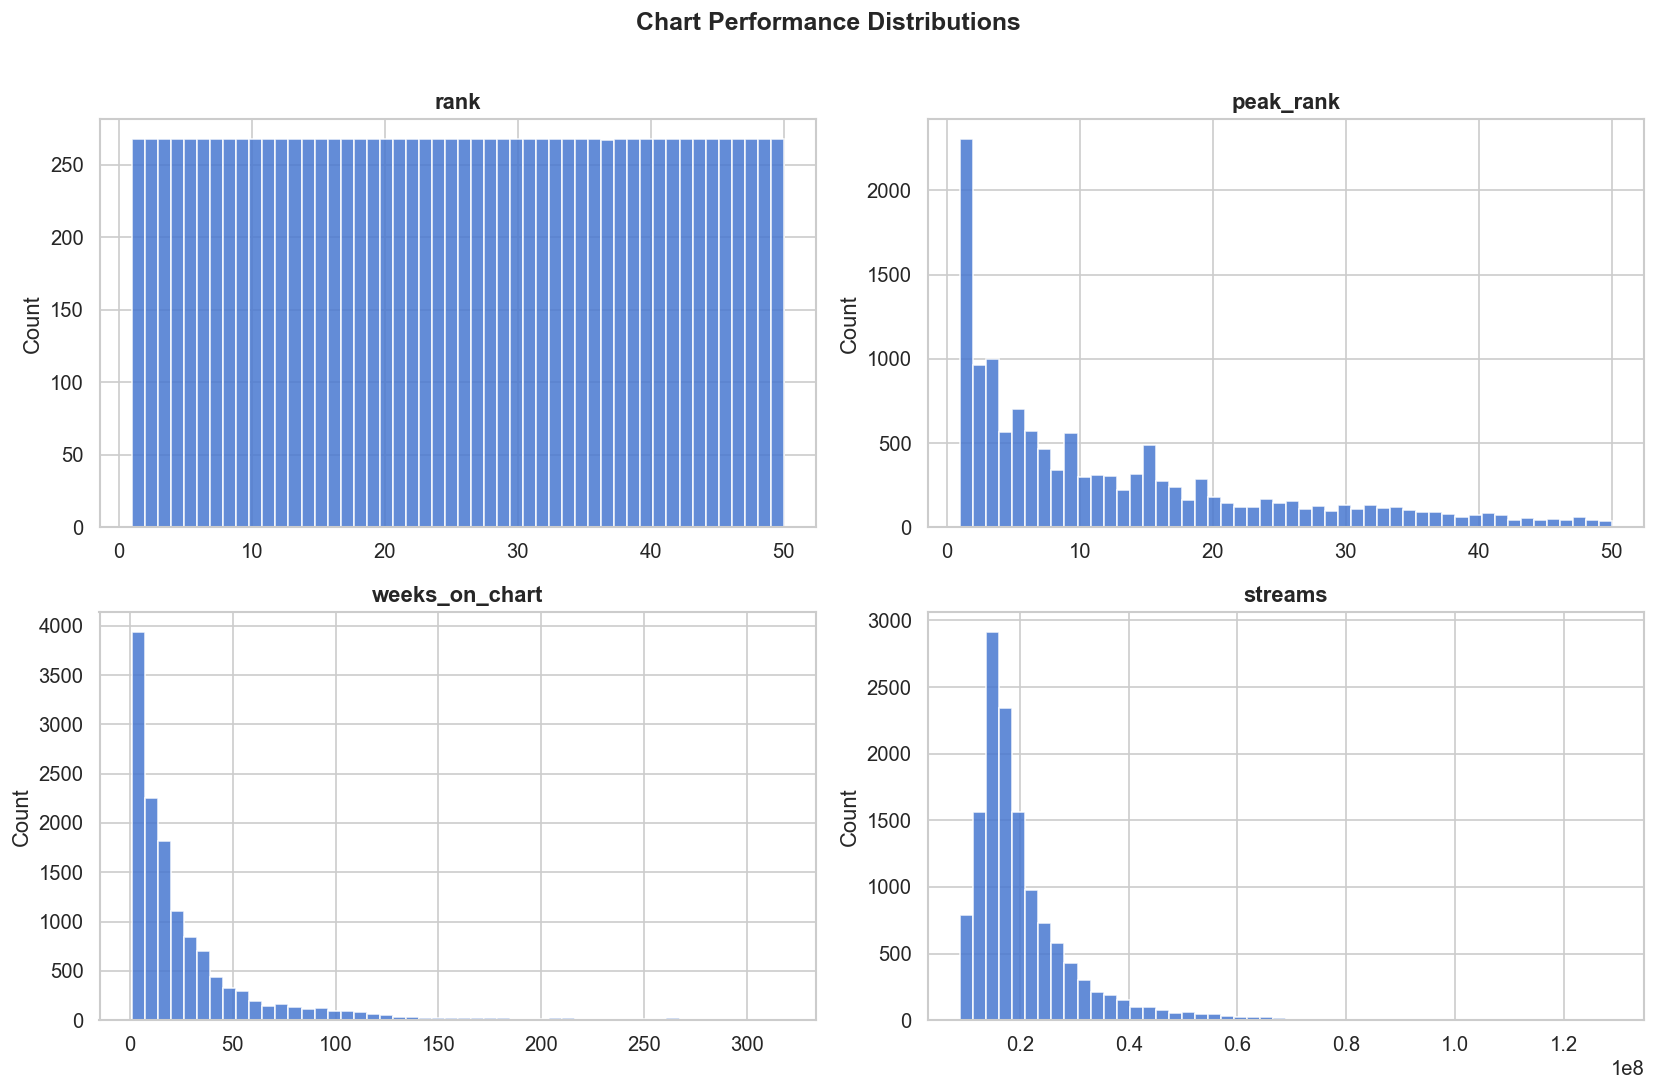

In [8]:
chart_cols = ["rank", "peak_rank", "weeks_on_chart", "streams"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flat, chart_cols):
    songs[col].dropna().hist(bins=50, ax=ax, edgecolor="white", alpha=0.85)
    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("Count")
fig.suptitle("Chart Performance Distributions", fontsize=15, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

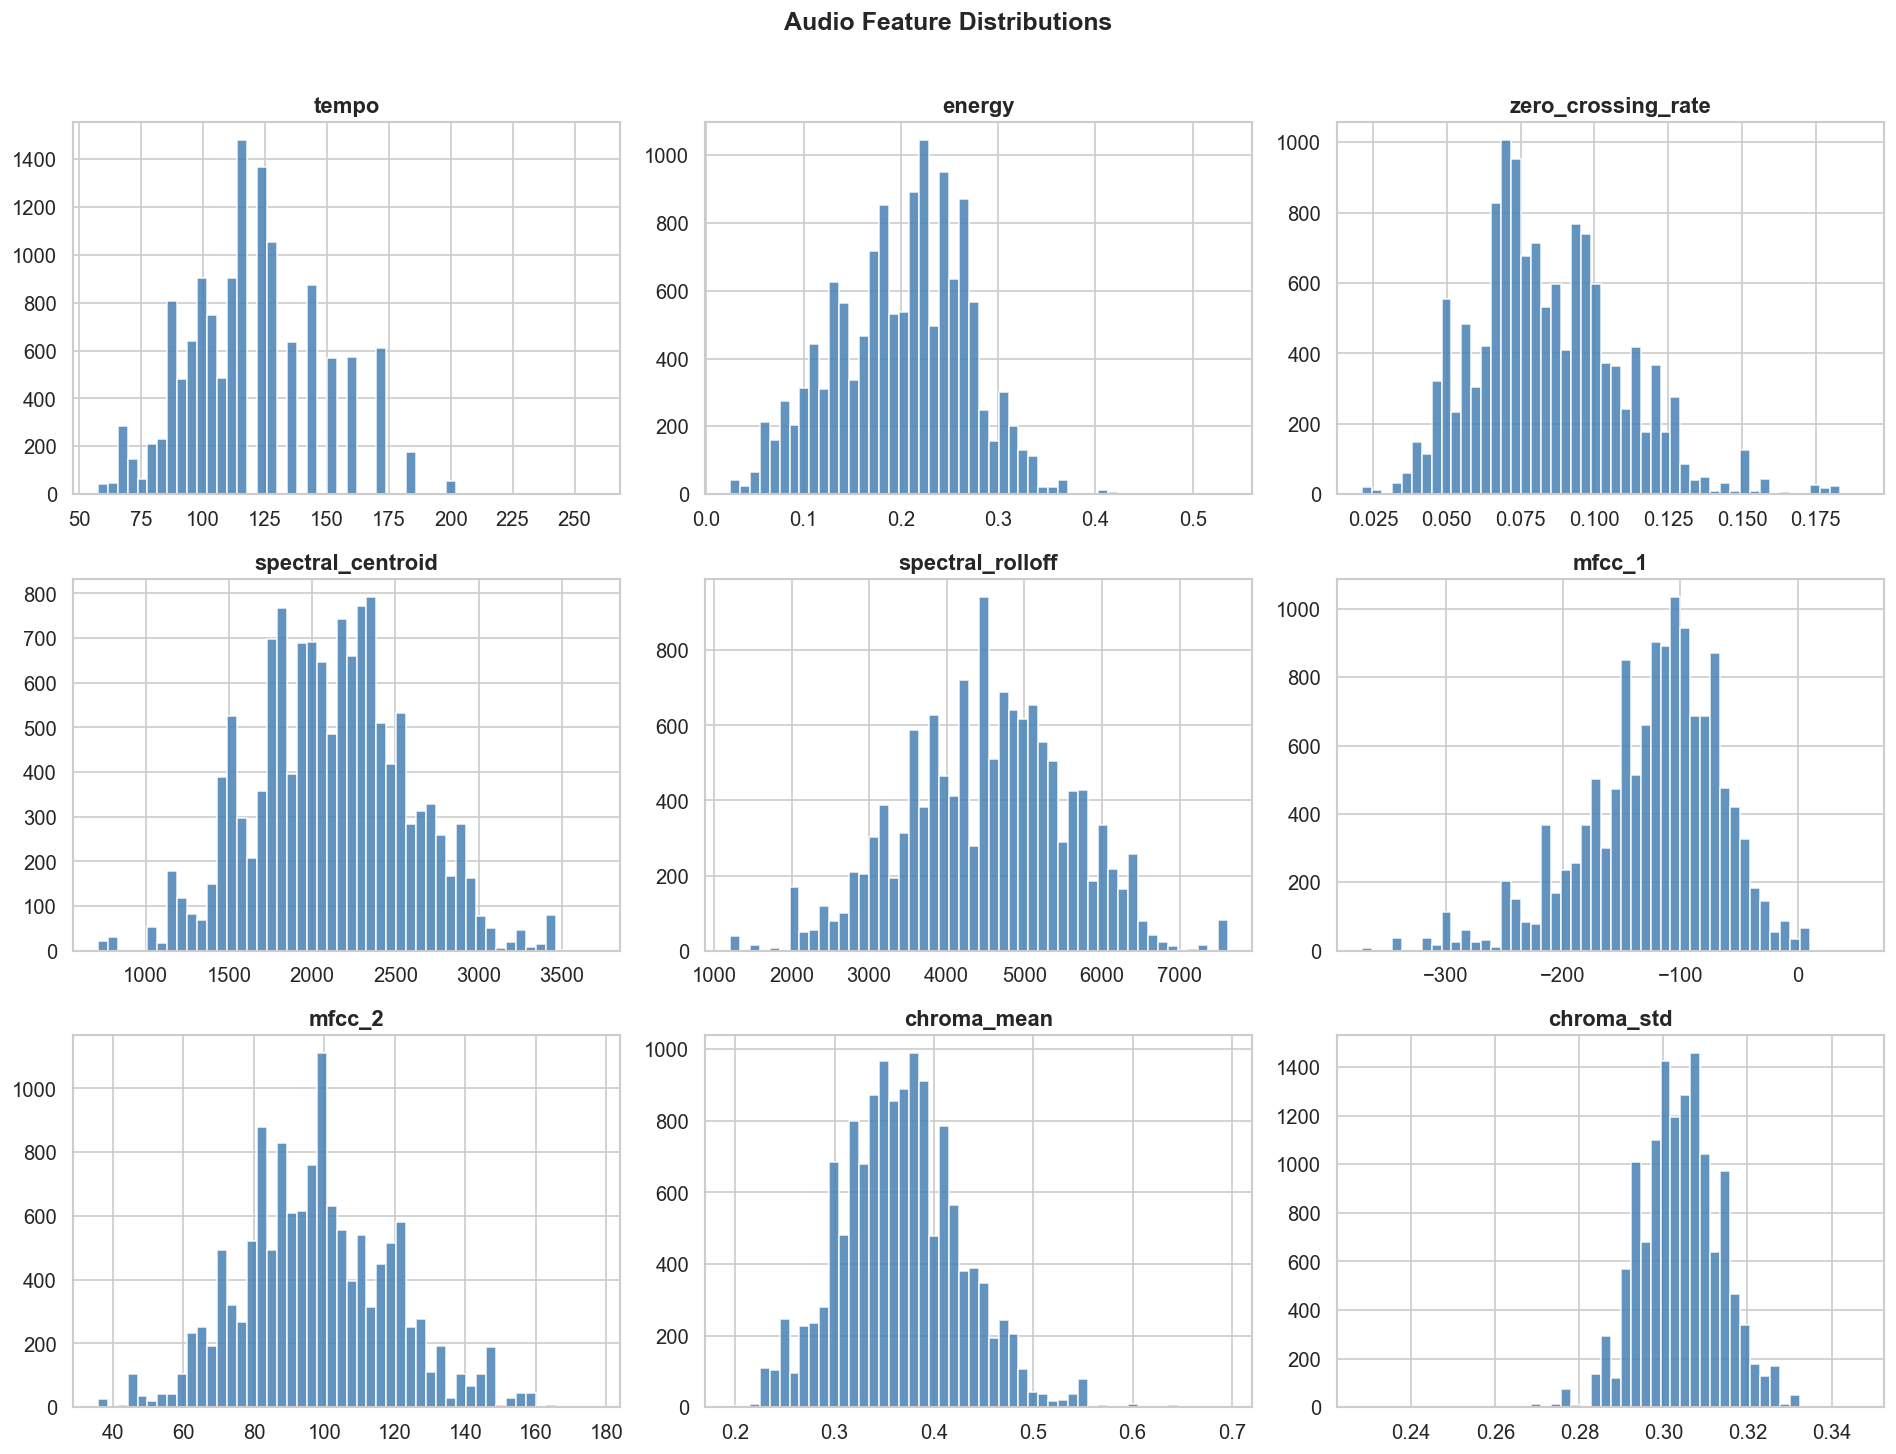

In [9]:
audio_cols = [
    "tempo", "energy", "zero_crossing_rate", "spectral_centroid",
    "spectral_rolloff", "mfcc_1", "mfcc_2", "chroma_mean", "chroma_std",
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.flat, audio_cols):
    songs[col].dropna().hist(bins=50, ax=ax, edgecolor="white", color="steelblue", alpha=0.85)
    ax.set_title(col, fontweight="bold")
fig.suptitle("Audio Feature Distributions", fontsize=15, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

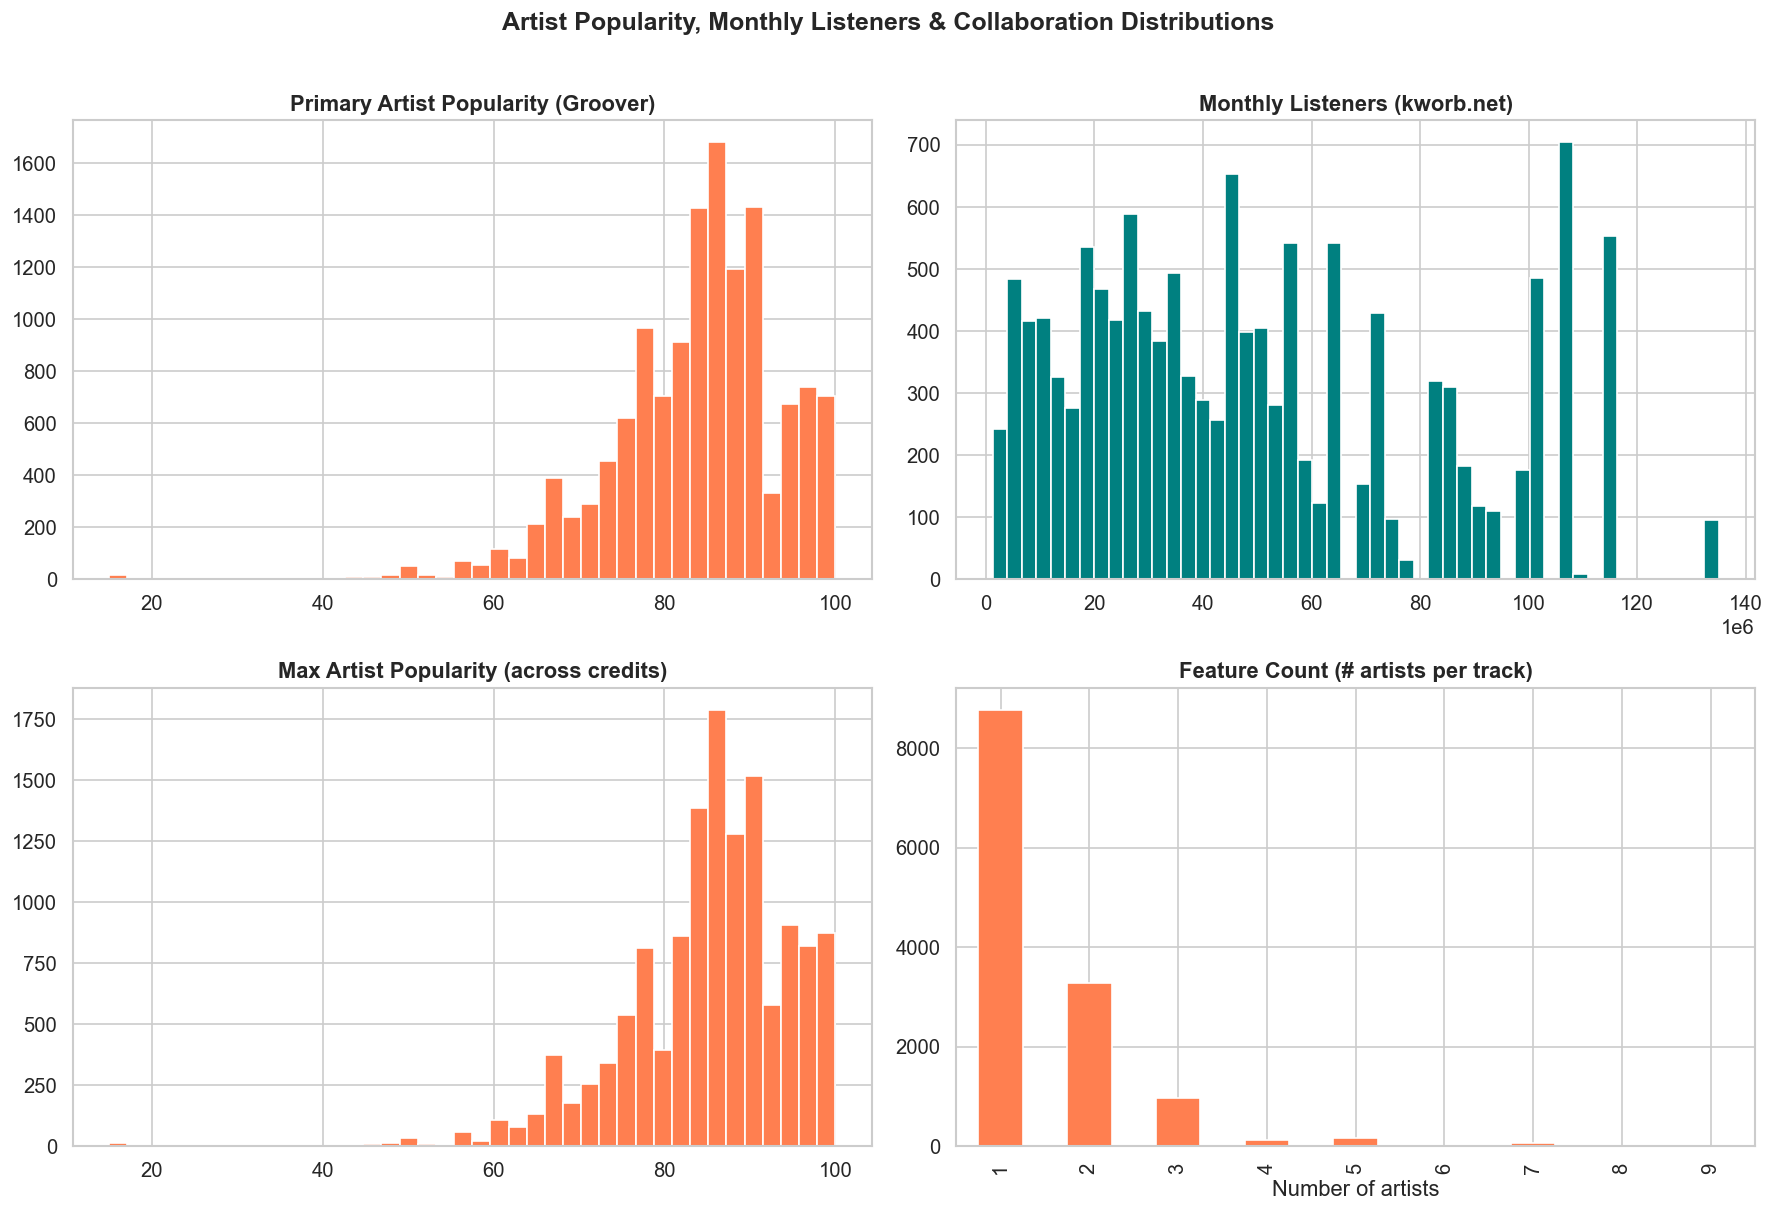

Monthly listeners — matched: 13,248, missing: 151


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

songs["primary_artist_popularity"].dropna().hist(bins=40, ax=axes[0, 0], edgecolor="white", color="coral")
axes[0, 0].set_title("Primary Artist Popularity (Groover)", fontweight="bold")

songs["monthly_listeners"].dropna().hist(bins=50, ax=axes[0, 1], edgecolor="white", color="teal")
axes[0, 1].set_title("Monthly Listeners (kworb.net)", fontweight="bold")
axes[0, 1].ticklabel_format(style="scientific", axis="x", scilimits=(6, 6))

songs["max_artist_popularity"].dropna().hist(bins=40, ax=axes[1, 0], edgecolor="white", color="coral")
axes[1, 0].set_title("Max Artist Popularity (across credits)", fontweight="bold")

songs["feature_count"].value_counts().sort_index().plot.bar(ax=axes[1, 1], color="coral", edgecolor="white")
axes[1, 1].set_title("Feature Count (# artists per track)", fontweight="bold")
axes[1, 1].set_xlabel("Number of artists")

fig.suptitle("Artist Popularity, Monthly Listeners & Collaboration Distributions",
             fontsize=15, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

print(f"Monthly listeners — matched: {songs['monthly_listeners'].notna().sum():,}, "
      f"missing: {songs['monthly_listeners'].isna().sum():,}")

## 4. Correlation Analysis

Full correlation heatmap of numeric features, followed by a focused view on how audio features relate to chart success metrics.

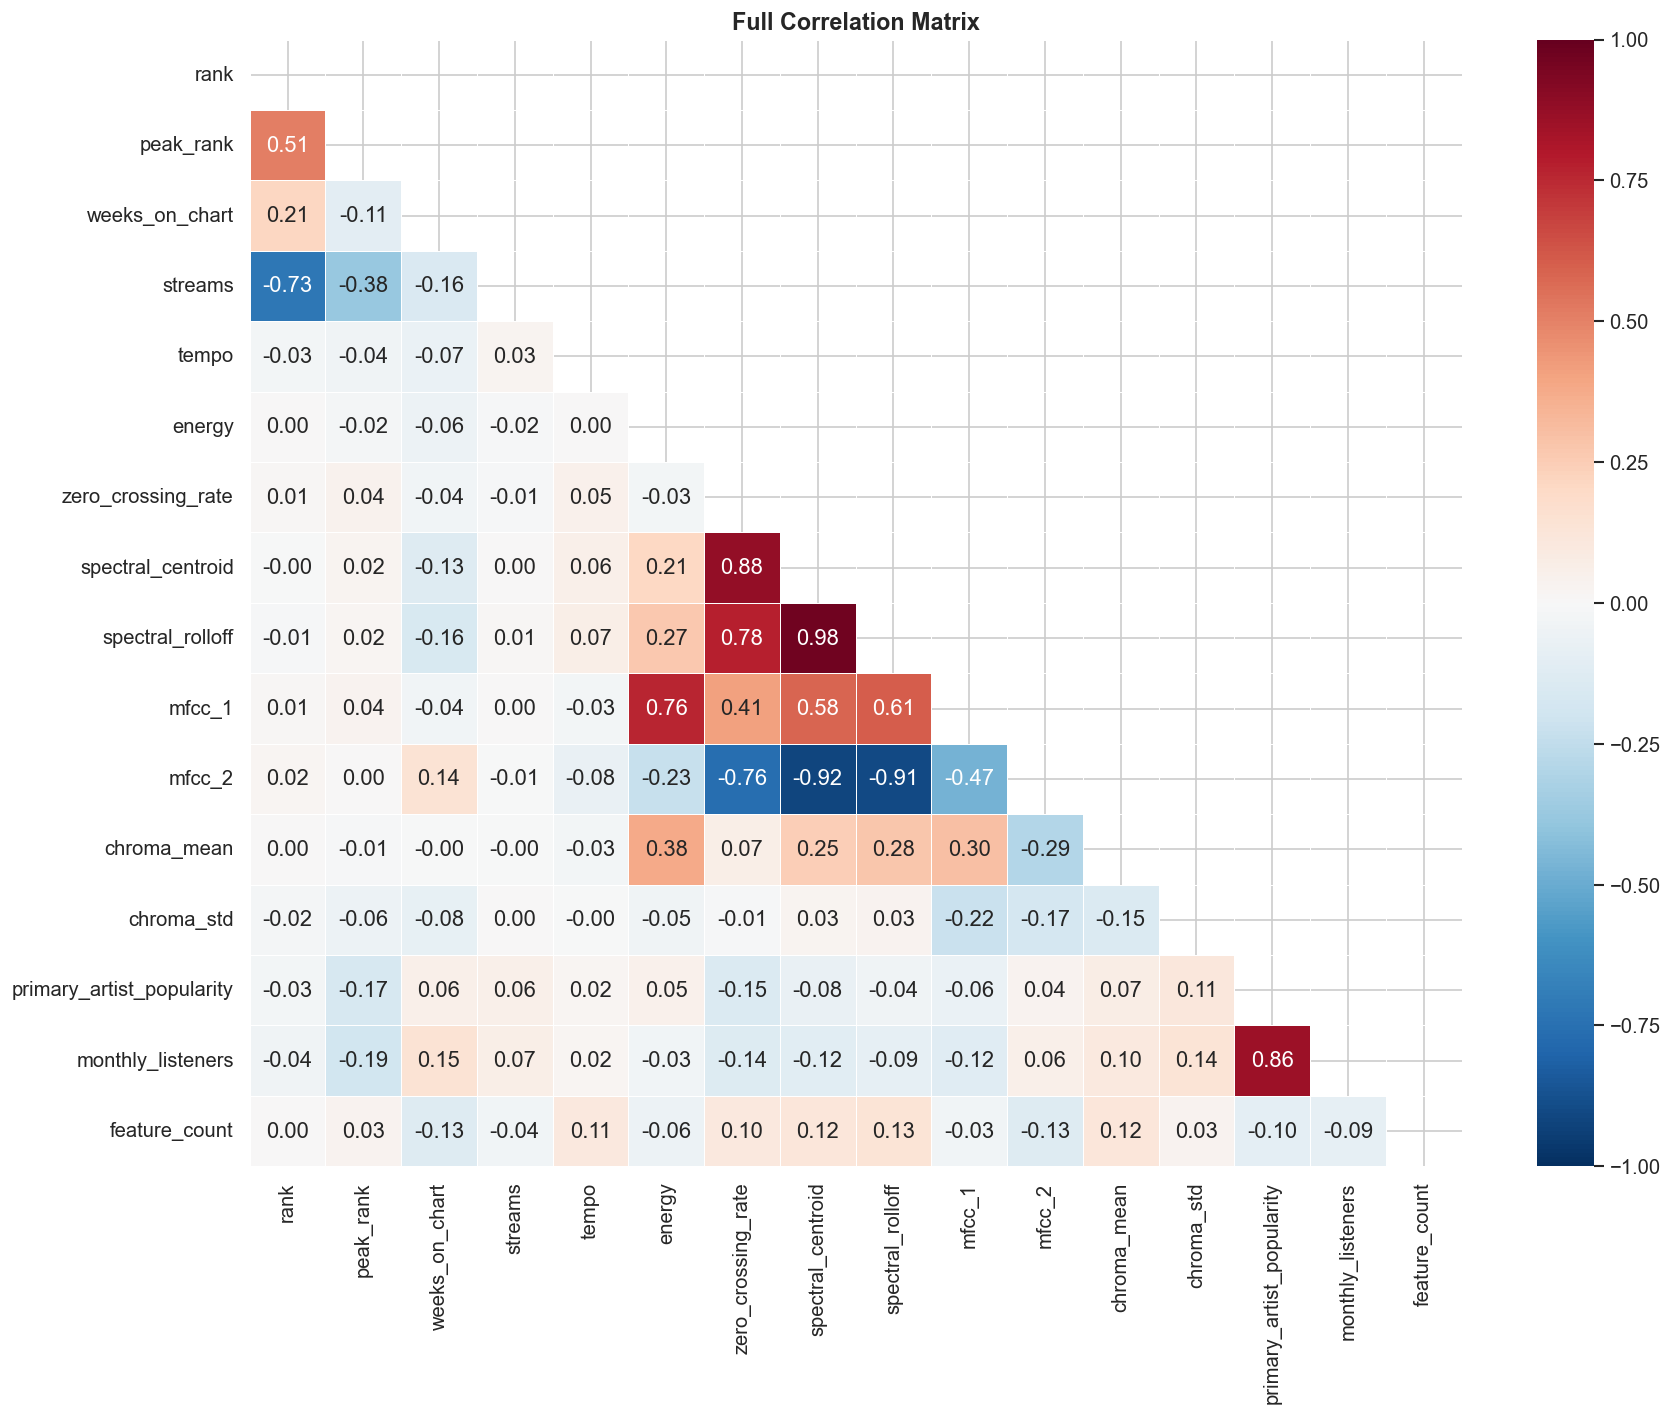

In [11]:
numeric_cols = [
    "rank", "peak_rank", "weeks_on_chart", "streams",
    "tempo", "energy", "zero_crossing_rate", "spectral_centroid",
    "spectral_rolloff", "mfcc_1", "mfcc_2", "chroma_mean", "chroma_std",
    "primary_artist_popularity", "monthly_listeners", "feature_count",
]

corr = songs[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(15, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Full Correlation Matrix", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

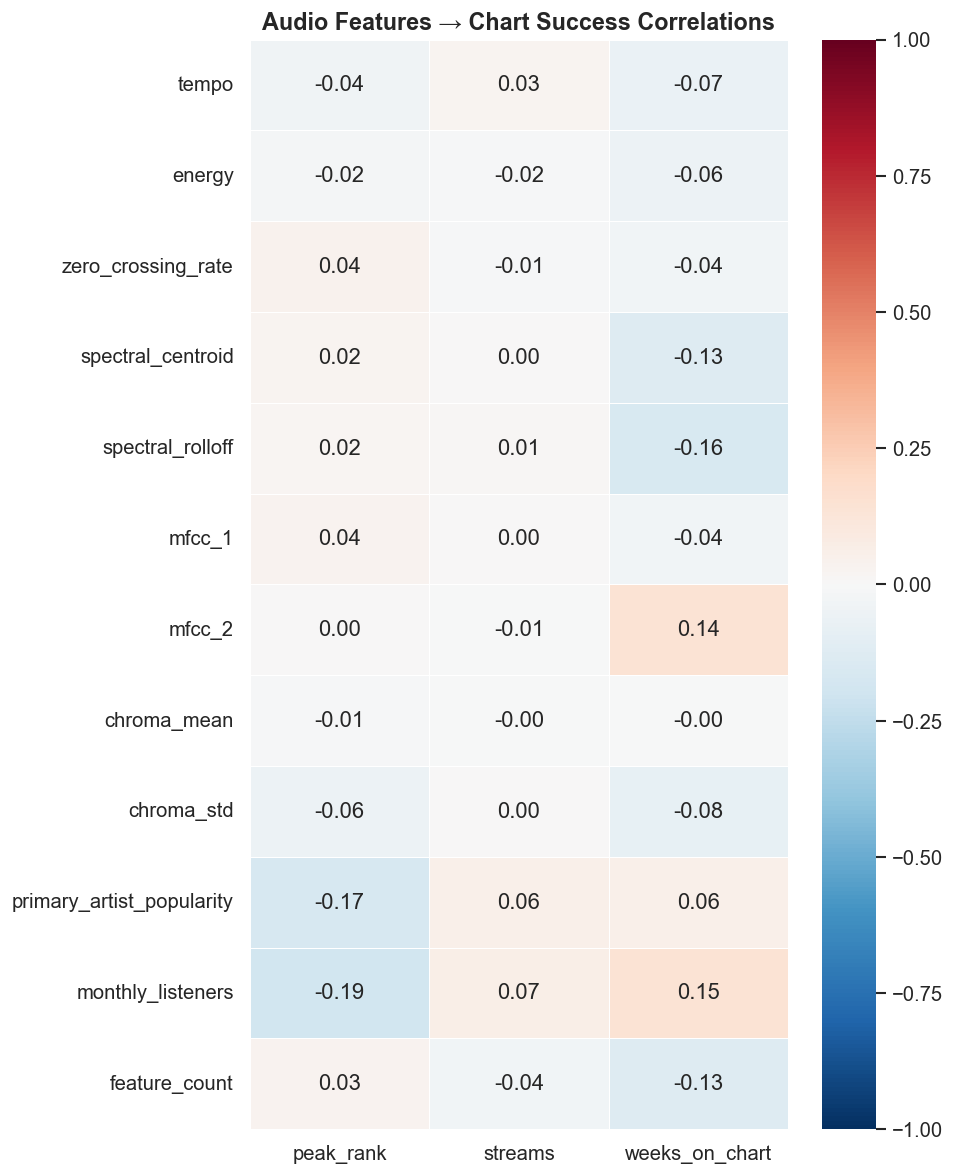

In [12]:
target_vars = ["peak_rank", "streams", "weeks_on_chart"]
feature_vars = [
    "tempo", "energy", "zero_crossing_rate", "spectral_centroid",
    "spectral_rolloff", "mfcc_1", "mfcc_2", "chroma_mean", "chroma_std",
    "primary_artist_popularity", "monthly_listeners", "feature_count",
]

focused_corr = songs[feature_vars + target_vars].corr().loc[feature_vars, target_vars]

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(focused_corr, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Audio Features → Chart Success Correlations", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

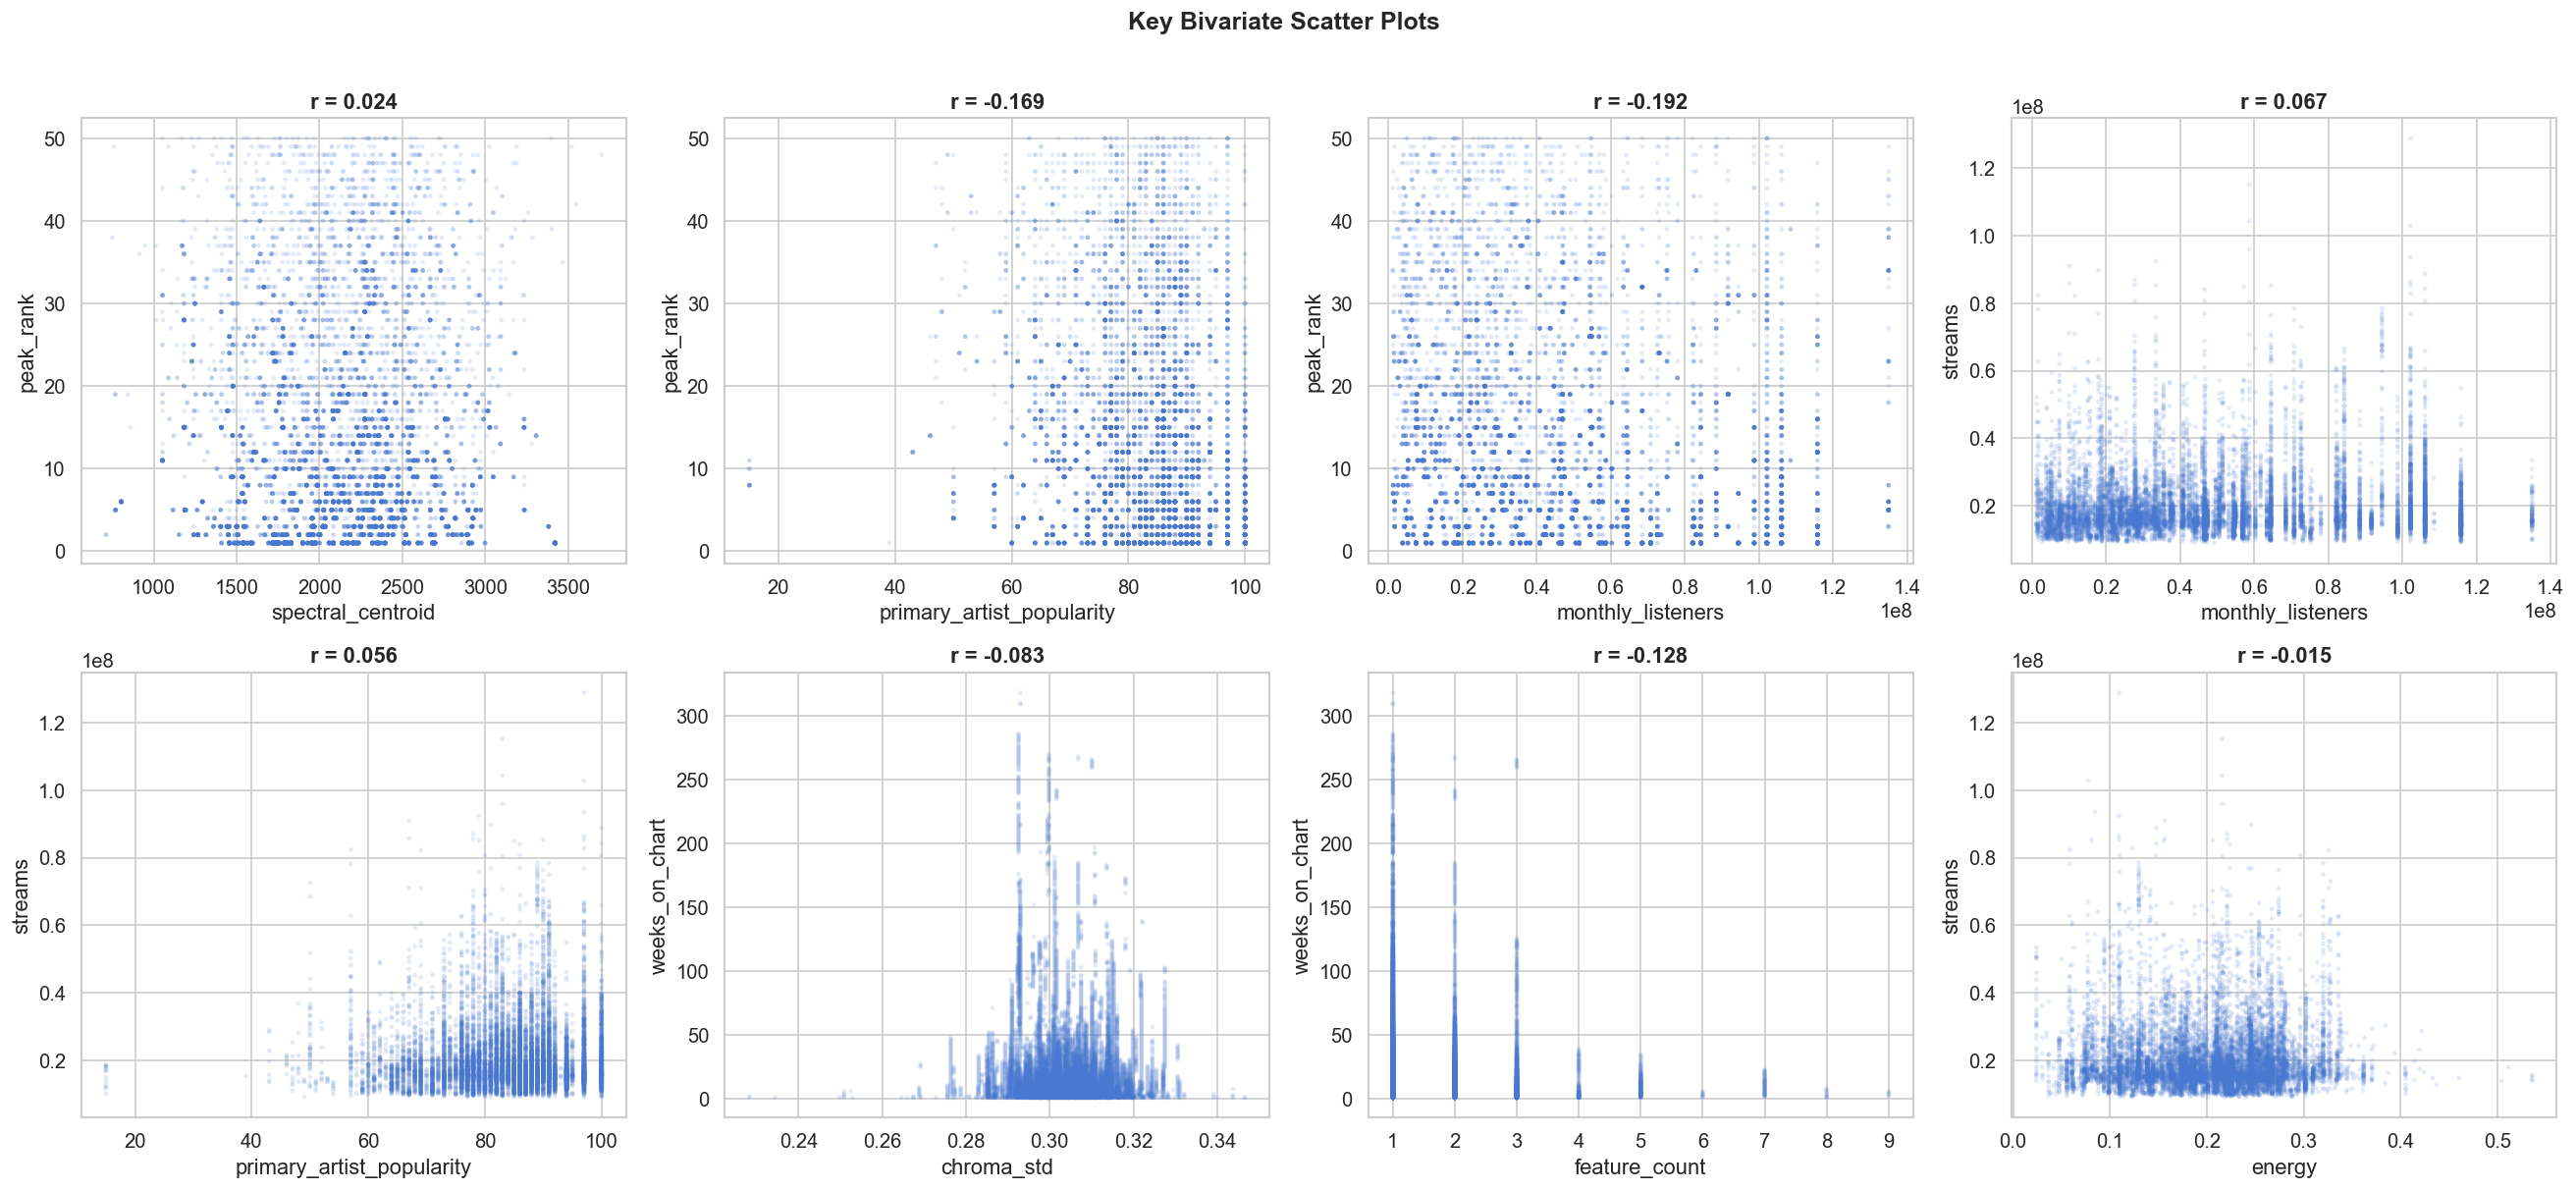

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
pairs = [
    ("spectral_centroid", "peak_rank"),
    ("primary_artist_popularity", "peak_rank"),
    ("monthly_listeners", "peak_rank"),
    ("monthly_listeners", "streams"),
    ("primary_artist_popularity", "streams"),
    ("chroma_std", "weeks_on_chart"),
    ("feature_count", "weeks_on_chart"),
    ("energy", "streams"),
]
for ax, (x, y) in zip(axes.flat, pairs):
    ax.scatter(songs[x], songs[y], alpha=0.15, s=8, edgecolors="none")
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    r = songs[[x, y]].dropna().corr().iloc[0, 1]
    ax.set_title(f"r = {r:.3f}", fontweight="bold")

fig.suptitle("Key Bivariate Scatter Plots", fontsize=15, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

---
## 5. Research-Question EDA

### RQ1 — Brand vs. Signal: Does artist popularity moderate spectral brightness → chart rank?

We split artists into **listener tiers** using `monthly_listeners` (scraped from kworb) and compare how `spectral_centroid` (brightness) relates to `peak_rank` within each tier. We also show the `primary_artist_popularity` tier view for comparison.

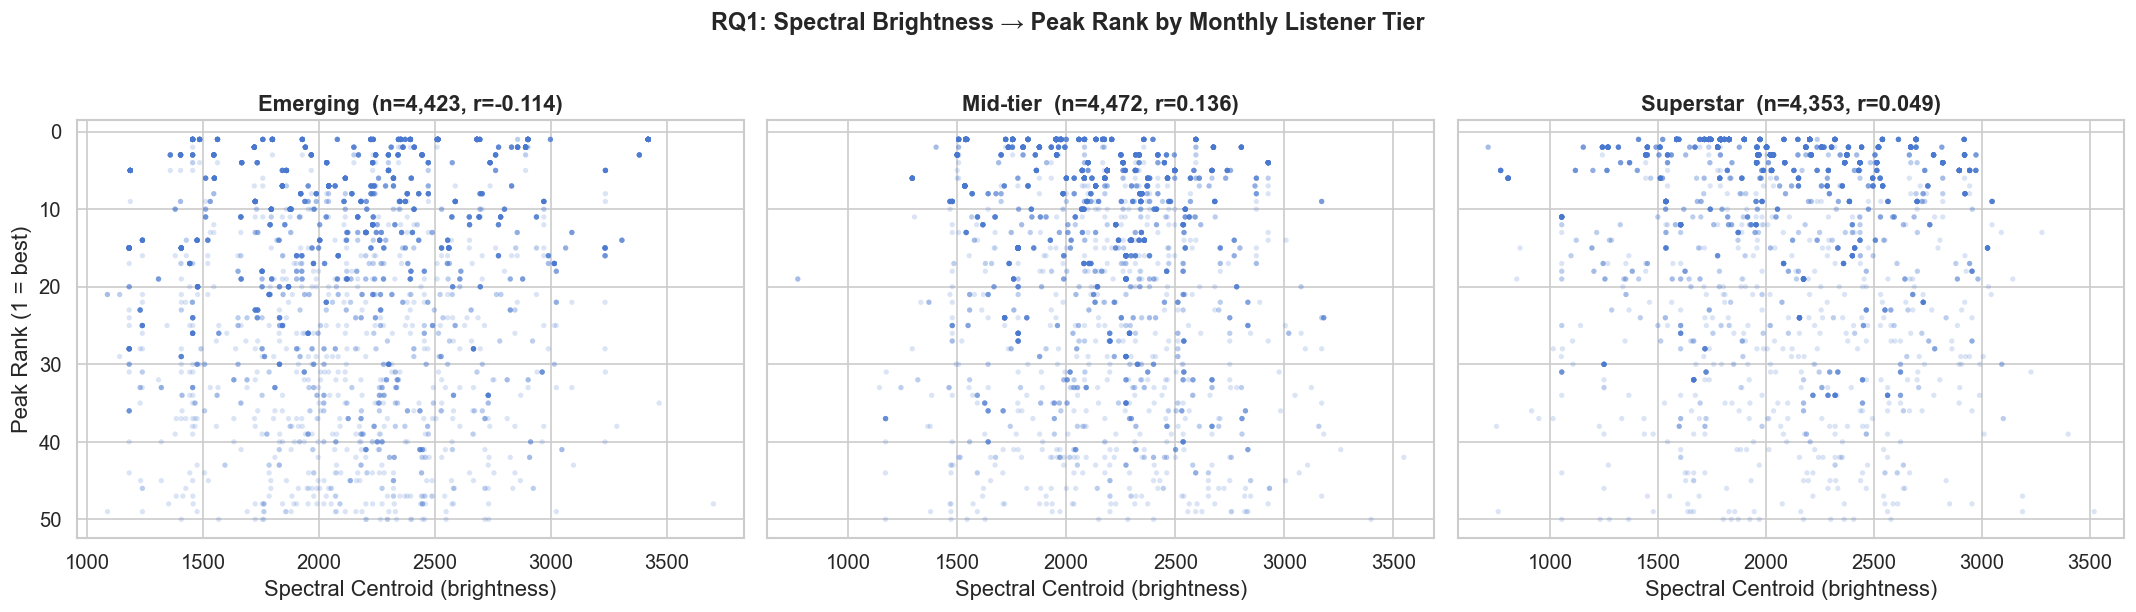

In [14]:
rq1 = songs.dropna(subset=["monthly_listeners", "spectral_centroid", "peak_rank"]).copy()

rq1["listener_tier"] = pd.qcut(
    rq1["monthly_listeners"], q=3,
    labels=["Emerging", "Mid-tier", "Superstar"]
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, tier in zip(axes, ["Emerging", "Mid-tier", "Superstar"]):
    sub = rq1[rq1["listener_tier"] == tier]
    ax.scatter(sub["spectral_centroid"], sub["peak_rank"], alpha=0.2, s=10, edgecolors="none")
    r = sub[["spectral_centroid", "peak_rank"]].corr().iloc[0, 1]
    ax.set_title(f"{tier}  (n={len(sub):,}, r={r:.3f})", fontweight="bold")
    ax.set_xlabel("Spectral Centroid (brightness)")
    if ax == axes[0]:
        ax.set_ylabel("Peak Rank (1 = best)")
    ax.invert_yaxis()

fig.suptitle("RQ1: Spectral Brightness → Peak Rank by Monthly Listener Tier",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

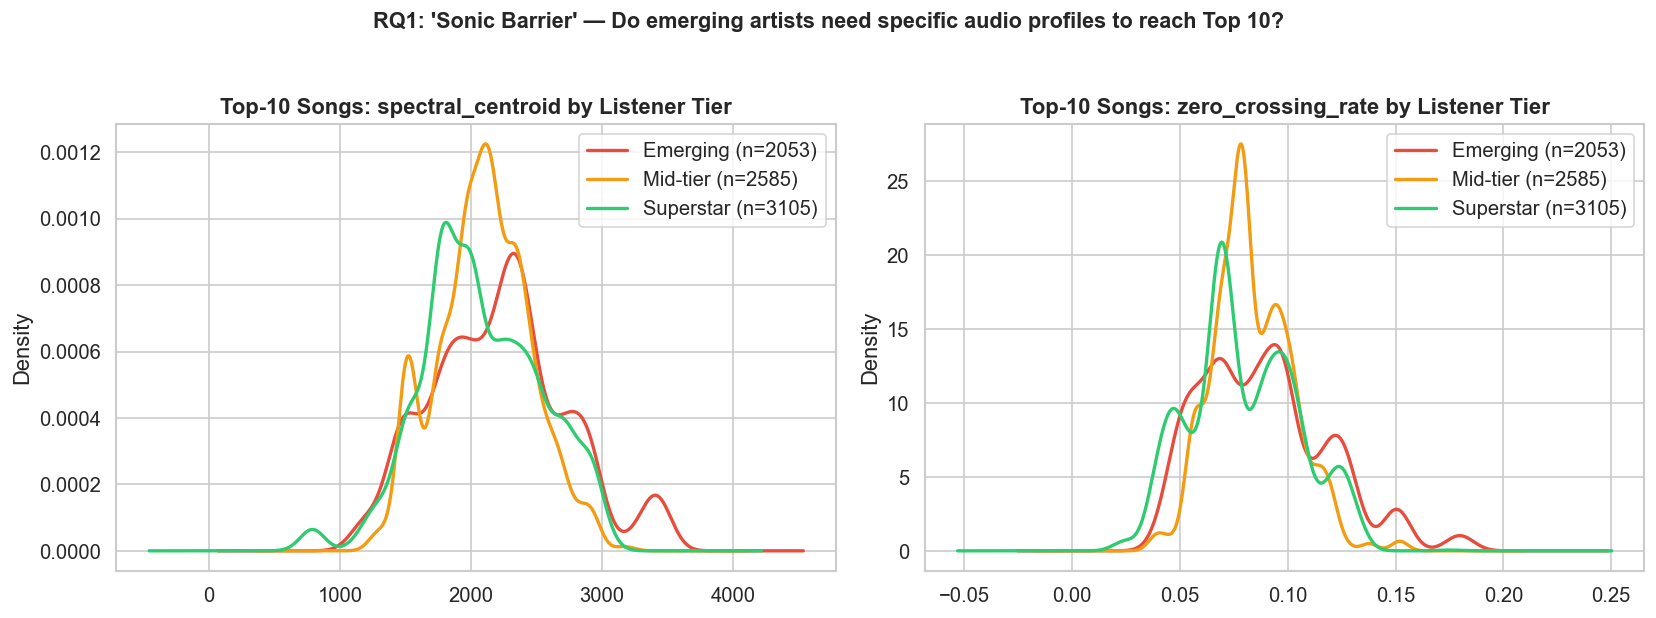

In [15]:
top10 = rq1[rq1["peak_rank"] <= 10]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat in zip(axes, ["spectral_centroid", "zero_crossing_rate"]):
    for tier, color in zip(["Emerging", "Mid-tier", "Superstar"], ["#e74c3c", "#f39c12", "#2ecc71"]):
        sub = top10[top10["listener_tier"] == tier]
        sub[feat].plot.kde(ax=ax, label=f"{tier} (n={len(sub)})", color=color, linewidth=2)
    ax.set_title(f"Top-10 Songs: {feat} by Listener Tier", fontweight="bold")
    ax.legend()

fig.suptitle("RQ1: 'Sonic Barrier' — Do emerging artists need specific audio profiles to reach Top 10?",
             fontsize=13, fontweight="bold", y=1.03)
fig.tight_layout()
plt.show()

In [16]:
print("=== RQ1: Audio feature summary — Top-10 songs by monthly-listener tier ===\n")
summary = top10.groupby("listener_tier")[
    ["spectral_centroid", "zero_crossing_rate", "spectral_rolloff", "energy", "monthly_listeners"]
].agg(["mean", "std"])
print(summary.round(2).to_string())

=== RQ1: Audio feature summary — Top-10 songs by monthly-listener tier ===

              spectral_centroid         zero_crossing_rate       spectral_rolloff          energy       monthly_listeners             
                           mean     std               mean   std             mean      std   mean   std              mean          std
listener_tier                                                                                                                         
Emerging                2215.92  512.58               0.09  0.03          4731.90  1160.52   0.20  0.07       16878506.30   8328017.00
Mid-tier                2096.28  352.60               0.08  0.02          4464.44   863.90   0.20  0.06       44922727.15   8695877.67
Superstar               2073.45  451.87               0.08  0.02          4471.30  1044.11   0.21  0.07       91499787.35  18415215.59


### RQ2 — Longevity Paradox: Collaborations × Harmonic Stability → Chart Longevity

We look at `weeks_on_chart` as a proxy for longevity, segmented by solo vs. collab tracks, and examine how `chroma_std` (harmonic instability) interacts.

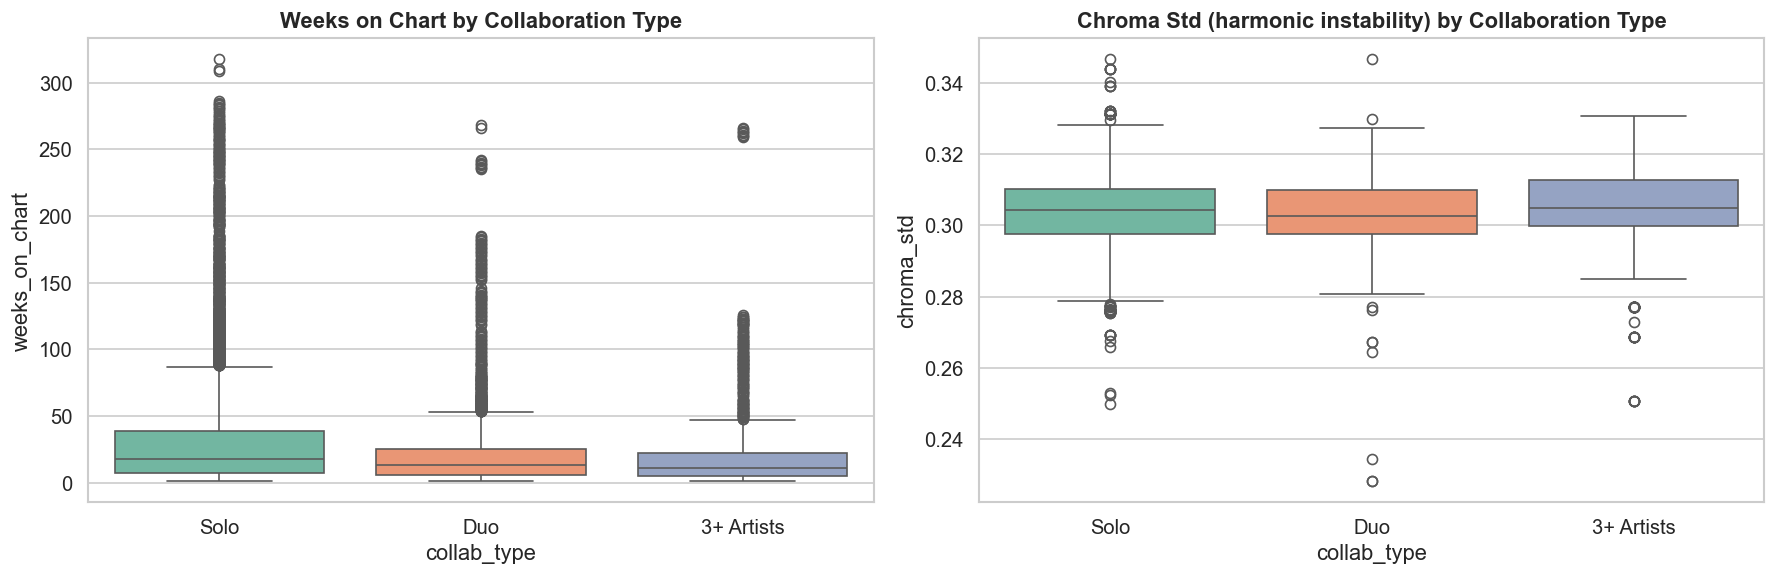

=== Median weeks on chart by collaboration type ===
collab_type
Solo          18.0
Duo           13.0
3+ Artists    11.0
Name: weeks_on_chart, dtype: float64


In [17]:
rq2 = songs.dropna(subset=["weeks_on_chart", "chroma_std", "feature_count"]).copy()
rq2["collab_type"] = rq2["feature_count"].apply(
    lambda x: "Solo" if x == 1 else ("Duo" if x == 2 else "3+ Artists")
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=rq2, x="collab_type", y="weeks_on_chart",
            order=["Solo", "Duo", "3+ Artists"], ax=axes[0], palette="Set2")
axes[0].set_title("Weeks on Chart by Collaboration Type", fontweight="bold")

sns.boxplot(data=rq2, x="collab_type", y="chroma_std",
            order=["Solo", "Duo", "3+ Artists"], ax=axes[1], palette="Set2")
axes[1].set_title("Chroma Std (harmonic instability) by Collaboration Type", fontweight="bold")

fig.tight_layout()
plt.show()

print("=== Median weeks on chart by collaboration type ===")
print(rq2.groupby("collab_type")["weeks_on_chart"].median().sort_values(ascending=False))

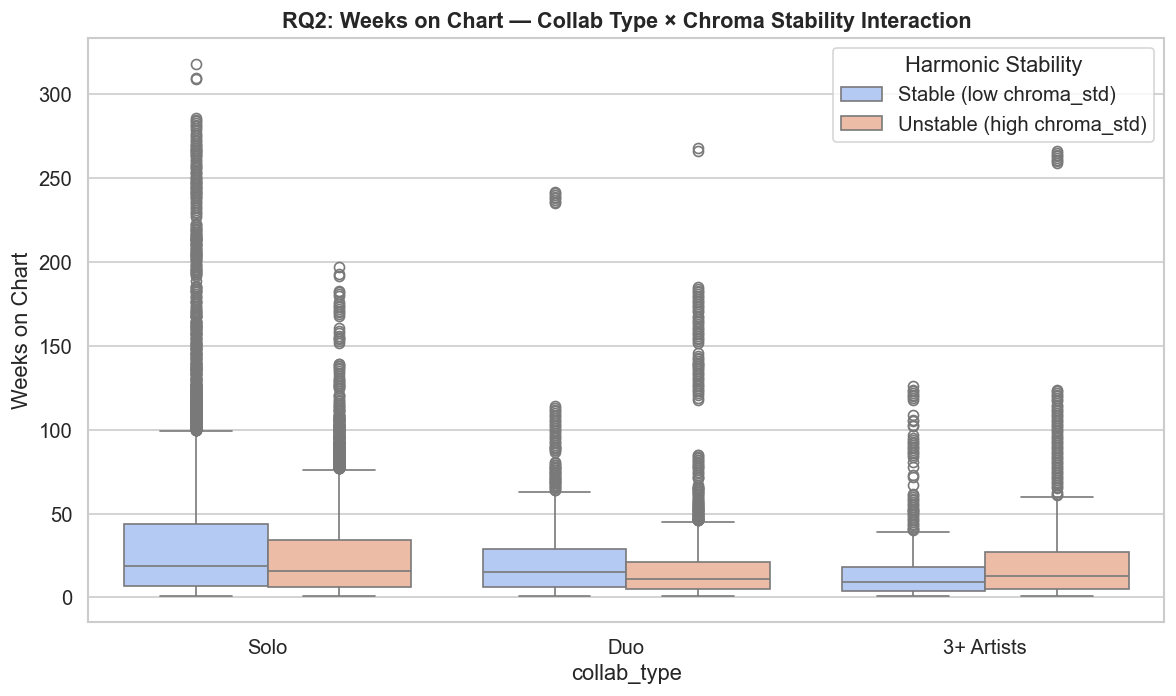

In [18]:
rq2["chroma_stability"] = pd.qcut(rq2["chroma_std"], q=2, labels=["Stable (low chroma_std)", "Unstable (high chroma_std)"])

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=rq2, x="collab_type", y="weeks_on_chart", hue="chroma_stability",
    order=["Solo", "Duo", "3+ Artists"], ax=ax, palette="coolwarm"
)
ax.set_title("RQ2: Weeks on Chart — Collab Type × Chroma Stability Interaction",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Weeks on Chart")
ax.legend(title="Harmonic Stability")
plt.tight_layout()
plt.show()

In [19]:
print("=== RQ2: Mean weeks on chart — Collab Type × Chroma Stability ===\n")
pivot = rq2.groupby(["collab_type", "chroma_stability"])["weeks_on_chart"].agg(["mean", "median", "count"])
print(pivot.round(2).to_string())

print("\n=== Correlation: chroma_std vs weeks_on_chart by collab type ===")
for ct in ["Solo", "Duo", "3+ Artists"]:
    sub = rq2[rq2["collab_type"] == ct]
    r = sub[["chroma_std", "weeks_on_chart"]].corr().iloc[0, 1]
    print(f"  {ct:>12s}: r = {r:.3f}  (n = {len(sub):,})")

=== RQ2: Mean weeks on chart — Collab Type × Chroma Stability ===

                                         mean  median  count
collab_type chroma_stability                                
3+ Artists  Stable (low chroma_std)     16.45     9.0    623
            Unstable (high chroma_std)  23.90    13.0    718
Duo         Stable (low chroma_std)     21.25    15.0   1789
            Unstable (high chroma_std)  21.08    11.0   1493
Solo        Stable (low chroma_std)     39.43    19.0   4323
            Unstable (high chroma_std)  25.29    16.0   4453

=== Correlation: chroma_std vs weeks_on_chart by collab type ===
          Solo: r = -0.127  (n = 8,776)
           Duo: r = -0.031  (n = 3,282)
    3+ Artists: r = 0.174  (n = 1,341)


### RQ3 — Popularity Premium: How much of streams is unexplained by audio features?

We preview the "Popularity Premium" concept by:
1. Checking how much variance in `streams` the audio features can explain (simple R²).
2. Examining the residuals by record label (`source`) and artist popularity.

Linear model R² (audio features → log streams): 0.0074
→ Audio features explain ~0.7% of variance in log(streams)
→ The remaining ~99.3% is the 'Popularity Premium' territory



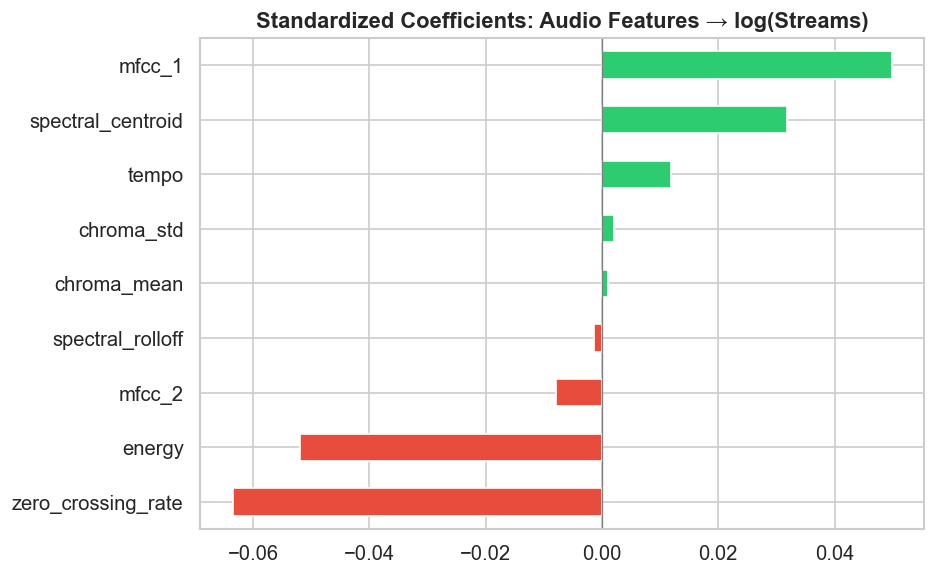

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

audio_features = [
    "tempo", "energy", "zero_crossing_rate", "spectral_centroid",
    "spectral_rolloff", "mfcc_1", "mfcc_2", "chroma_mean", "chroma_std",
]

rq3 = songs.dropna(subset=audio_features + ["streams", "source", "primary_artist_popularity"]).copy()
rq3["log_streams"] = np.log1p(rq3["streams"])

X = rq3[audio_features]
y = rq3["log_streams"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression().fit(X_scaled, y)
rq3["predicted_log_streams"] = model.predict(X_scaled)
rq3["residual"] = rq3["log_streams"] - rq3["predicted_log_streams"]

r2 = r2_score(y, rq3["predicted_log_streams"])
print(f"Linear model R² (audio features → log streams): {r2:.4f}")
print(f"→ Audio features explain ~{r2*100:.1f}% of variance in log(streams)")
print(f"→ The remaining ~{(1-r2)*100:.1f}% is the 'Popularity Premium' territory\n")

coefs = pd.Series(model.coef_, index=audio_features).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
coefs.plot.barh(ax=ax, color=["#e74c3c" if c < 0 else "#2ecc71" for c in coefs])
ax.set_title("Standardized Coefficients: Audio Features → log(Streams)", fontweight="bold")
ax.axvline(0, color="gray", linewidth=0.8)
fig.tight_layout()
plt.show()

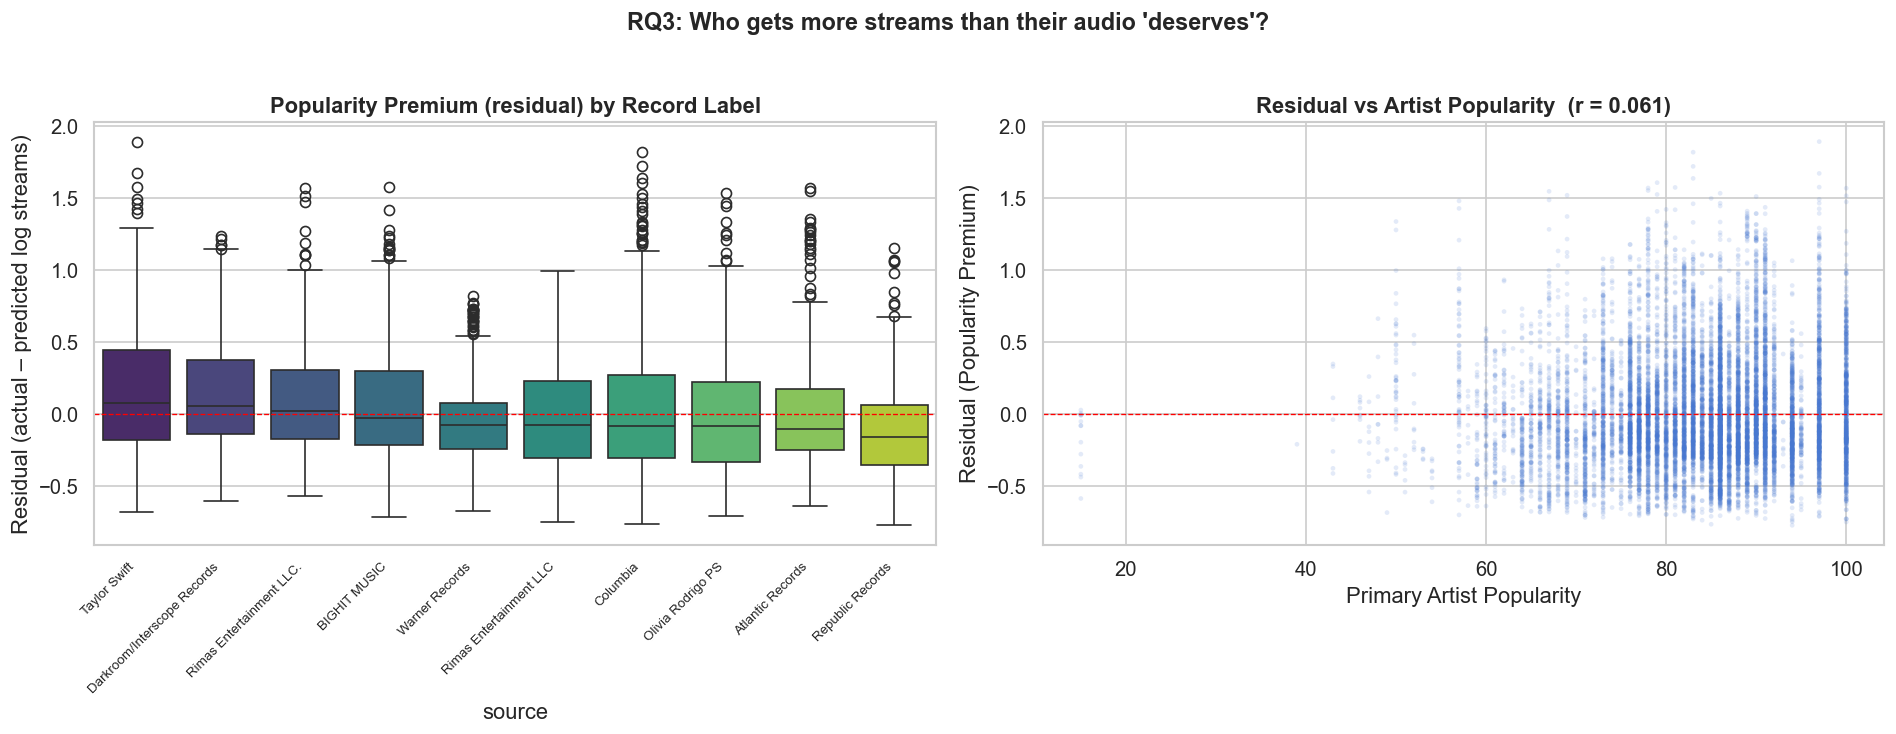

In [21]:
top_labels = rq3["source"].value_counts().head(10).index
rq3_top = rq3[rq3["source"].isin(top_labels)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

label_medians = rq3_top.groupby("source")["residual"].median().sort_values(ascending=False)
sns.boxplot(data=rq3_top, x="source", y="residual",
            order=label_medians.index, ax=axes[0], palette="viridis")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right", fontsize=8)
axes[0].set_title("Popularity Premium (residual) by Record Label", fontweight="bold")
axes[0].axhline(0, color="red", linestyle="--", linewidth=0.8)
axes[0].set_ylabel("Residual (actual – predicted log streams)")

axes[1].scatter(rq3["primary_artist_popularity"], rq3["residual"], alpha=0.15, s=8, edgecolors="none")
axes[1].set_xlabel("Primary Artist Popularity")
axes[1].set_ylabel("Residual (Popularity Premium)")
r = rq3[["primary_artist_popularity", "residual"]].corr().iloc[0, 1]
axes[1].set_title(f"Residual vs Artist Popularity  (r = {r:.3f})", fontweight="bold")
axes[1].axhline(0, color="red", linestyle="--", linewidth=0.8)

fig.suptitle("RQ3: Who gets more streams than their audio 'deserves'?",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

In [22]:
print("=== RQ3: Median 'Popularity Premium' (residual) by top labels ===\n")
label_stats = rq3_top.groupby("source")["residual"].agg(["median", "mean", "count"]).sort_values("median", ascending=False)
print(label_stats.round(3).to_string())

print("\n=== Popularity Premium by artist popularity quartile ===")
rq3["pop_quartile"] = pd.qcut(rq3["primary_artist_popularity"], q=4, labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"])
print(rq3.groupby("pop_quartile")["residual"].agg(["median", "mean", "count"]).round(3).to_string())

=== RQ3: Median 'Popularity Premium' (residual) by top labels ===

                             median   mean  count
source                                           
Taylor Swift                  0.074  0.174    485
Darkroom/Interscope Records   0.058  0.151    358
Rimas Entertainment LLC.      0.023  0.116    278
BIGHIT MUSIC                 -0.028  0.084    357
Warner Records               -0.073 -0.052    538
Rimas Entertainment LLC      -0.079 -0.020    533
Columbia                     -0.081  0.022   1001
Olivia Rodrigo PS            -0.084 -0.007    298
Atlantic Records             -0.101  0.006    466
Republic Records             -0.159 -0.112    455

=== Popularity Premium by artist popularity quartile ===
              median   mean  count
pop_quartile                      
Q1 (low)      -0.092 -0.034   3607
Q2            -0.071 -0.001   4340
Q3            -0.068  0.018   2267
Q4 (high)     -0.067  0.026   3185


---
## 6. EDA Summary & Next Steps

**Key observations to watch for after running the notebook:**

| Research Question | What to look for |
|---|---|
| **RQ1 (Brand vs. Signal)** | Compare the correlation (r) between spectral_centroid and peak_rank across tiers. If emerging artists show a stronger/different correlation, the "sonic barrier" hypothesis holds. |
| **RQ2 (Longevity Paradox)** | Check if collab tracks with *unstable* harmony (high chroma_std) have shorter chart life. The interaction plot is the key visual. |
| **RQ3 (Popularity Premium)** | The R² tells us how much audio explains. Residual differences across labels/popularity quartiles quantify brand power. |

**Next steps:** Move from EDA into formal statistical modeling — interaction regression for RQ1/RQ2, and residual analysis pipeline for RQ3.

In [23]:
songs.to_csv("raw_spotify_top50_eda_input.csv", index=False)